## Анализ данных о Нобелевских лауреатах

### **Контекст проекта**
В этом задании мы будем работать с датасетом о лауреатах Нобелевской премии. Ваша задача — распарсить и проанализировать эти данные, ответив на ключевые вопросы о закономерностях вручения премий, демографических характеристиках лауреатов и исторических тенденциях.

### **Этап 1: Подготовка данных**

**Задача:** На этом этапе вам надо собрать структурированный список словарей с информацией о лауреатах и призах. Приведем начало нужного нам датасета.

``` {code:python}
[{'id': '745',
  'name': 'A. Michael Spence',
  'gender': 'male',
  'birth_year': 1943,
  'country_birth': 'USA',
  'country_now': 'USA',
  'prizes_relevant': [{'prize_amount': 10000000,
    'prize_amount_adjusted': 15547541,
    'award_year': 2001,
    'category_en': 'Economic Sciences',
    'prize_status': 'received'}],
  'type_': 'person'},
 {'id': '102',
  'name': 'Aage N. Bohr',
  'gender': 'male',
  'birth_year': 1922,
  'country_birth': 'Denmark',
  'country_now': 'Denmark',
  'prizes_relevant': [{'prize_amount': 630000,
    'prize_amount_adjusted': 4304697,
    'award_year': 1975,
    'category_en': 'Physics',
    'prize_status': 'received'}],
  'type_': 'person'}]
  ```

Поскольку информация о лауреатах-людях и лауреатах-организациях структурирована по-разному, а также из-за того, что часть полей в json могут отсутстввовать, необходимо реализовать функции для процессинга словарей, которые будут достаточно обобщаемыми для обоих типов данных.

**Что нужно сделать:**

На входе информация о конкретном лауреате представляет из себя кучу вложенных друг в друга словарей. Из этой структуры нам надо получить плоский словарь вида {atribute: value}, где atribute --- это один из небольшого множества интересных нам атрибутов. При этом в исходном файле 
1. пути к атрибутам могут иметь разную длину
2. атрибуты могут отсутствовать
3. атрибуты могут нуждаться в дополнительной обработке (например, поле id в исходных словарях записано как строка.)

Поскольку наивная реализация такого обработчика оказывается довольно громоздкой, вам нужно создать файл json_dict_processing.py, в котором реализован высокоуровневый функционал для решения задачи "обработать вложенный json-словарь"

Главное требование к интерфейсу: 
по (вложенному) словарю о лауреате и конфигу (см ниже) надо получить плоский словарь вида {atribute: value}.

Достичь этого можно, например, таким набором функций

* `extract_nested_value(obj, keys)` - извлекает значение из вложенных структур данных по цепочке ключей

* `process_dictionary_with_config(dictionary, config)` - обрабатывает один словарь согласно словару-конфигу (формат конфига см ниже.)

* `process_list_of_dicts_with_config(list_of_dicts, config)` - обрабатывает список словарей, эта функция нужна чтобы обработать список призов.

* `create_processor(config, list_processor=False)` - создает готовый процессор с предзагруженной конфигурацией. В случае, если list_processor == True, внутрь процессора подается process_list_of_dicts_with_config, иначе process_dictionary_with_config.

**Замечание насчет последней функции.**

Планируемое применение этой функции примерно такое:
`laureate_processor = create_processor(PERSON_CONFIG, list_processor=False)`

То есть, create_processor возвращает функцию, которая реализует функционал process_dictionary_with_config но с уже заполненным конфигом. Это повышает читаемость кода и снижает риск перепутать конфиги из-за дублирования кода.


Помимо этого нужно создать файлы-конфиги для данных по призам, лауреатам-людям, и лауреатам-организациям.

КОНФИГ для функций process_dictionary_with_config и process_list_of_dicts_with_config имеет следующий вид
```python
  {'атрибут_который_берем_сырым': ['путь', 'к', 'данным'],  # или
  'атрибут_который_нужно_обработать': (['путь', 'к', 'данным'], функция_обработки)}
  ```
В случае, если атрибут можно взять в итоговый датасет сырым, в values() словаря-конфига будет список path_list.
Если же атрибут еще надо обработать, для него в поле config[attribute] будет tuple вида (path_list, function).

Примеры атрибутов, которые можно взять сырыми: имя, размер приза. Примеры атрибутов, которые нужно обработать: год вручения приза (в сырых данных есть только полная дата, записанная как строка)

После того, как будет создан core.py, создайте конфиги laureates_configs.py и prizes_configs.py

Постарайтесь провалидировать код с помощью assert-ов, вызываемых в ноутбуке или в .py-файлах.

пример использования: 

assert 1 == True

**Валидация**

В вашем случае assert должен взять простой словарик с одним вложенным полем и какой-нибудь конфиг-файл.
Также убедитесь, что при обработке данных собственно по лауреатам в них нет странностей (смотрите ниже) 

**Атрибуты для ПРИЗА (CONFIG_PRIZE, prizes_configs.py)**

- `prize_amount` - сумма приза → `prizeAmount`
- `prize_amount_adjusted` - скорректированная сумма приза → `prizeAmountAdjusted`
- `award_year` - год вручения приза (преобразуется в целое число) → `awardYear`
- `category_en` - категория на английском → `category.en`
- `prize_status` - статус приза → `prizeStatus`

**Атрибуты для ЧЕЛОВЕКА-ЛАУРЕАТА (CONFIG_PERSON, laureates_configs.py)**

- `id` - уникальный идентификатор → `id`
- `name` - имя лауреата → `knownName.en`
- `gender` - пол → `gender`
- `birth_year` - год рождения (извлекается из даты) → `birth.date`
- `country_birth` - страна рождения → `birth.place.country.en`
- `country_now` - текущая страна → `birth.place.countryNow.en`
- `prizes_relevant` - список призов лауреата → `nobelPrizes` (обрабатывается процессором призов, который вы задаете в конфиге для призов)

**Атрибуты для ОРГАНИЗАЦИИ-ЛАУРЕАТА (CONFIG_ORG, laureates_configs.py)**

- `id` - уникальный идентификатор → `id`
- `name` - название организации → `orgName.en`
- `founded_year` - год основания (извлекается из даты) → `founded.date`
- `country_founded` - страна основания → `founded.place.country.en`
- `country_now` - текущая страна → `founded.place.countryNow.en`
- `prizes_relevant` - список призов организации → `nobelPrizes` (обрабатывается процессором призов, который вы задаете в конфиге для призов)

**Вспомогательные функции:**

- `process_year(year_string)` - извлекает год из строки даты (формат "YYYY-MM-DD"). Функция находится в файле laureates_configs.py
- `prize_processor()` - создает процессор для обработки списков призов. Функция находится в файле prizes_configs.py
- `person_processor()` - создает процессор для данных о людях-лауреатах. Функция находится в файле laureates_configs.py
- `org_processor()` - создает процессор для данных об организациях-лауреатах. Функция находится в файле laureates_configs.py

___________

После изучения type hinting, выяснилось, что довольно сложно hintить сложные структуры. Но так как это делать надо, иначе Pylance ругается везде, то приходится переопределять собственные типы с помощью классов, которые мы по идее пройдем только дальше. Иначе у паттерна получается тип: dict[str, dict[str, str | list[dict[str, dict[str, str | Callable[[Any], int]]]] | Callable[[str], int]]], который все равно далее вызывает ошибку, из-за того, что Pylance не знает, какое значение будет возвращено при получении значения по ключу, и не уверен, что вернулась строка из словаря, а не какой-либо другой тип.
И то, при использовании такого type hinting приходится сначала делать тип PatternType для типа паттерна, а потом передавать в функцию Mapping[str, Union[PatternPathType, PatternPathWithTransformType, PatternListType, PatternValueType]], так как иначе Pylance не может интерпретировать объект никак, кроме как object, и не может понять, какие у него могут быть методы.

В итоге был создан сначала файл с максимальным type hinting, после чего было обнаружено, что в требованиях нигде про type hinting не упоминается, что означает, что за него только снимут баллы из-за того, что длины строк становятся огромными. Поэтому type hinting остался минимальный

In [4]:
import requests

URL_LAUREATES = f'https://api.nobelprize.org/2.1/laureates?limit=1200'

laureates_response = requests.get(URL_LAUREATES)
laureates = laureates_response.json()

In [6]:
from laureates_configs import org_processor, person_processor  # реализуйте эти функции согласно описанной выше логике

def get_laureate_data(laureate):
    """
    Определите тип лауреата and соотв образом обработайте данных.
    
    Args:
        laureate: Dictionary with laureate data
        
    Returns:
        Processed laureate data with added 'type_' field ('person' or 'org')
        
    Determines type by:
    - 'knownName' key → person (uses process_persons)
    - 'orgName' key → org (uses process_orgs)
    """
    processor_person = person_processor()
    processor_org = org_processor()
    if 'knownName' in laureate:
        return processor_person(laureate)
    elif 'orgName' in laureate:
        return processor_org(laureate)
    else:
        raise ValueError("По словарю невозможно определить тип данных")


laureates_data = []

for laureate in laureates['laureates']:
    laureates_data.append(get_laureate_data(laureate))



### **Этап 2: EDA лауреатов**

EDA или Exploratory Data Analysis - первый шаг при работе с любыми данными.

Чтобы начать работать с этой секцией, проведите проведите чисто технический анализ собранных данных.

1. Сколько всего записей?
2. Все ли значения полей заполнены?
3. Если нет, сколько пропусков в каждом из полей? Выведите ответ на этот вопрос в формате `{'field_name': missing_values}`. А какая доля пропусков?
5. Каковы максимальные и минимальные значения поля id и каким годам награждения они соответствуют? Есть ли записи с повторяющимися id? Есть ли пары айди, которые в отсортированном массиве айдишников различаются более, чем на один? 

При реализации ответов на эти вопросы, пользуйтесь теми же принципами, что описаны выше. Можете начать с плохого хакерского кода, однако в таком случае в маркдауне пропишите, как будете его обобщать и разносить по функциям и модулям. (об этом ниже)

В основном EDA пользуйтесь аккуратным кодом, разбитым на функции и файлы.

In [9]:
from basic_technic_analysis import basic_laureates_analysis

basic_laureates_analysis(laureates_data)

Всего 1018 записей
Пропущенные значения:
{'country_birth': 4, 'country_founded': 4, 'country_now': 8, 'founded_year': 1}
Доля пропущенных значений:
country_birth: 0.004
country_now: 0.008
country_founded: 0.143
founded_year: 0.036
Всего 1018 записей
Минимальный id: 1, года: [1901]
Максимальный id: 1060, года: [2025]
Нет записей с одинаковым id
Есть записи с id отличающимися более, чем на 1



Поскольку это курс по Python, а не по статистике или визуализации данных, мы не задаем жесткие рамки того, что вы должны проанализировать.
Однако это отличная возможность представить себя в роли разработчика базы данных или, например, библиотеки pandas.

В коде нужно соблюдать следующие правила:

1. должны быть реализованы  несколько способов работы с данными (среднее/медианное/максимальное значение метрики, количество примеров, вывод топ-N объектов по значению метрики).
2. анализ выбранных вами тем должен включать в себя анализ метрик в тотале, по категориям и в динамике по годам или десятилетиям.
3. проанализировать стоит 2-3 темы. Вы можете использовать темы ниже или взять свои.
2. вывод ноутбука должен быть понятен обывателю. Это может быть визуализация в matplotlib/seaborn. Сопровождайте вывод markdown-ячейками с вашими  мыслями, пояснениями и инсайтами, которые удалось извлечь.
3. Нельзя использовать pandas и numpy, но можно вдохновляться их интерфейсом и функционалом при дизайне ваших функций.


Из пункта 2 следует, что вам придется работать не только с атрибутами лауреатов, но и самих призов.
Информацию о призах нужно доставать и записывать как атрибут уже лауреата. Функции, работающие с призами (например, факт того, что лауреат отказался от какого-то из призов) можно реализовать в ноутбуке, но если вы создаете более общие вспомогательные функции, выносите их в отдельные модули.

Мы рекомендуем следующую структуру кода:

* `dataset_helpers.py` в котором реализованы фильтрация списка словарей (плоских) по условиям (аналог sql-ного where), а также аналог sql-ного групбая. А также функция для применения агрегаций к списку словарей
* `aggregations.py` в котором реализованы функции расчета среднего/медианы/других эвристик и мб вывод топ n-значений по какой-то метрике.
* `atribute_manager.py` в котором реализован переиспользуемый интерфейс для добавления (и мб удаления) полей.

Замечание насчет group-by. 

На игрушесном примере она может работать примерно так:
```
    Входные данные: [
        {'name': 'Alice', 'country': 'USA', 'age': 25},
        {'name': 'Bob', 'country': 'UK', 'age': 30},
        {'name': 'Charlie', 'country': 'USA', 'age': 25}
    ]
    
    group_by_attributes(data, ['country', 'age']) → {
        ('USA', 25): [
            {'name': 'Alice', 'country': 'USA', 'age': 25},
            {'name': 'Charlie', 'country': 'USA', 'age': 25}
        ],
        ('UK', 30): [
            {'name': 'Bob', 'country': 'UK', 'age': 30}
        ]
    }
```

Замечание насчет agregations.py
1. Агрегации соответственно должны применяться к спискам вида [
    {'name': 'Alice', 'country': 'USA', 'age': 25},
    {'name': 'Charlie', 'country': 'USA', 'age': 25}
]
2. Пользуйтесь модулем statistics из стандартной библиотеки питона.


Эта структура одна из возможных для организации вашего кода, главное, чтобы эти достаточно общие функции блыи переиспользованы

----------

При анализе данных вам понадобятся более конкретные функции, например filter_by_num_prizes или output_metric_by_category. Их пишите прямо в ноутбуке и сопровождайте коментами.

Ниже мы приводим некоторые примеры вопросов, которые может быть интересно задать к данным, но если у вас есть желание, можете поисследовать датасет с любой интересной вам стороны!


**2.1. Топ-статистика по странам**
- Определите топ-5 стран по общему количеству лауреатов
- Постройте аналогичные рейтинги отдельно по категориям (физика, химия, медицина и т.д.)

**2.2. Возраст при награждении**
- Рассчитать средний возраст лауреатов на момент получения **первого** приза. Рассмотрите только лауреатов-людей.
- Исследуйте, как средний возраст получения первого приза различается по категориям
- Различаются ли средний и медианный возрасты? 

**2.3. Гендерное распределение**
- Как менялось количество женщин-лауреатов по десятилетиям?
- Сравните распределение лауреаток по категориям. Выведите значения суммарно за все годы и по декадам.
- В какой из категорий больше всего женщин лауреаток изначально и в последние пару десятилетий?

**2.4. Миграции лауреатов**
- У скольки лауреатов исходная страна и страна на момент вручения нобелевской премии различаются? Всегда ли это различие объясняется миграцией? Добавьте вспомогательное поле 'country_of_origin_adjusted_for_migration', чтобы различие между этим полем и страной на момент вручения объяснялось миграцией.
- Выявите страны с наибольшей долей "оттекших" и "притекших" лауреатов.
- Есть ли оттоки среди организаций?

**2.5. Многократные лауреаты**
- Найдите лауреатов, получившие больше одного приза. Кто получил больше 2 раз? 
- Совпадает ли категория второго приза с первой?  
- Сколько в среднем времени прошло между получением первой и второй премии?

**2.6 Отказы от премий**
- Определите, в каких категориях чаще отказывались от премий?
- Есть ли отказы среди организаций?

**2.1. Топ-статистика по странам**
- Определите топ-5 стран по общему количеству лауреатов
- Постройте аналогичные рейтинги отдельно по категориям (физика, химия, медицина и т.д.)

In [15]:
def table_to_plot_table(data, lbl_name, val_name, sorted_by_lbl=False):
    if sorted_by_lbl:
        data = sorted(data, key=lambda d: d[lbl_name], reverse=True)
    else:
        data = sorted(data, key=lambda d: d[val_name], reverse=True)
    labels = [d[lbl_name] for d in data]
    values = [d[val_name] for d in data]
    return labels, values

def autopct_fmt(vals):
    total = sum(vals)
    def fmt(pct):
        count = int(round(pct * total / 100.0))
        return f"{pct:.1f}%\n({count})"
    return fmt

In [17]:
from dataset_helpers import where, group_by, order_by, limit, rename_column, operation_column
from prizes_aggregation import prizes_aggregation
from pprint import pprint
from copy import deepcopy
import matplotlib.pyplot as plt

table = prizes_aggregation(laureates_data)
###2.1
search_table = deepcopy(table)
grouped_country = group_by(search_table, "SELECT country_birth COUNT(id) GROUP BY country_birth")
limited_country = limit(order_by(grouped_country, "count(id)", True), 5)
result_table = rename_column(limited_country, "count(id)", "ppl_num")
pprint(result_table)

[{'country_birth': 'USA', 'ppl_num': 295},
 {'country_birth': 'United Kingdom', 'ppl_num': 94},
 {'country_birth': 'Germany', 'ppl_num': 80},
 {'country_birth': 'France', 'ppl_num': 60},
 {'country_birth': 'Sweden', 'ppl_num': 30}]


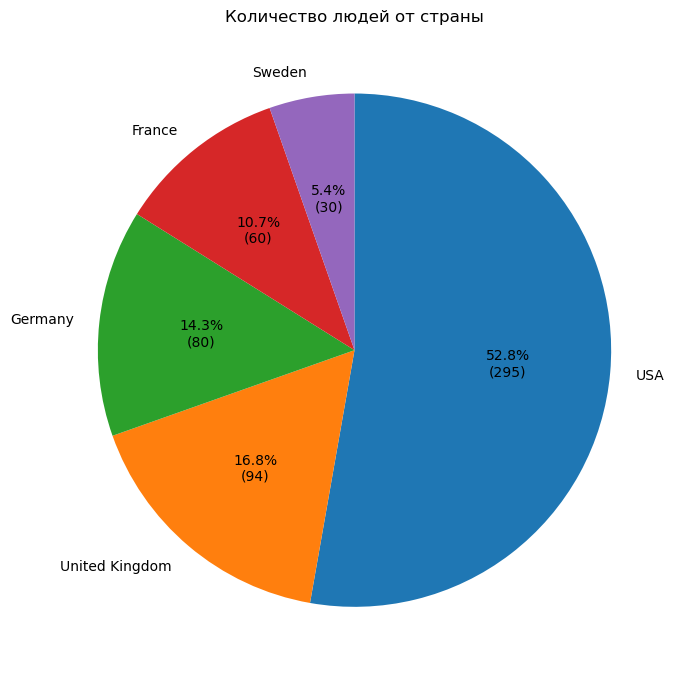

In [19]:
labels, values = table_to_plot_table(result_table, "country_birth", "ppl_num")

plt.figure(figsize=(7, 7))
plt.pie(
    values,
    labels=labels,
    autopct=autopct_fmt(values),
    startangle=90,
    counterclock=False,
)
plt.title("Количество людей от страны")
plt.tight_layout()
_ = plt.show()

In [21]:
search_table = deepcopy(table)
grouped_category = group_by(search_table, "SELECT category_en COUNT(id) GROUP BY category_en")
limited_category = limit(order_by(grouped_category, "count(id)", True), 5)
result_table = rename_column(limited_category, "count(id)", "ppl_num")
pprint(result_table)

[{'category_en': 'Physiology or Medicine', 'ppl_num': 232},
 {'category_en': 'Physics', 'ppl_num': 229},
 {'category_en': 'Chemistry', 'ppl_num': 198},
 {'category_en': 'Peace', 'ppl_num': 140},
 {'category_en': 'Literature', 'ppl_num': 122}]


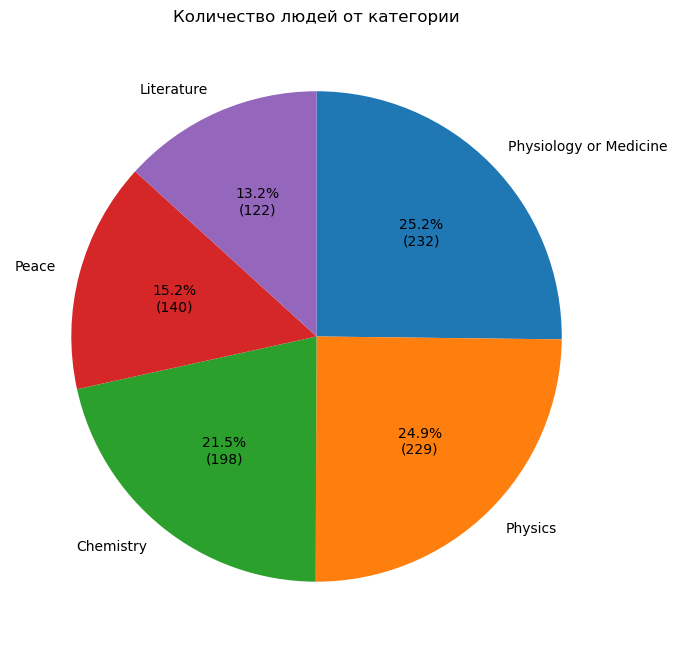

In [23]:
labels, values = table_to_plot_table(result_table, "category_en", "ppl_num")

plt.figure(figsize=(7, 7))
plt.pie(
    values,
    labels=labels,
    autopct=autopct_fmt(values),
    startangle=90,
    counterclock=False,
)
plt.gca().set_aspect("equal")
plt.title("Количество людей от категории")
plt.tight_layout()
_ = plt.show()

**2.2. Возраст при награждении**
- Рассчитать средний возраст лауреатов на момент получения **первого** приза. Рассмотрите только лауреатов-людей.
- Исследуйте, как средний возраст получения первого приза различается по категориям
- Различаются ли средний и медианный возрасты? 

In [26]:
### 2.2
search_table = deepcopy(table)
whered_people = where(search_table, "prize_no", lambda x: x == 1)
differed_people = operation_column(whered_people, ["award_year", "birth_year"], lambda x: x[0] - x[1])
renamed_people = rename_column(differed_people, "fun(award_year, birth_year)", "age_at_win")
filtered_people = where(renamed_people, "gender", lambda x: x)
grouped_people = group_by(filtered_people, "SELECT AVG(age_at_win) prize_status GROUP BY prize_status")
result_table = rename_column(grouped_people, "avg(age_at_win)", "avg_age_at_win")
pprint(result_table)

[{'avg_age_at_win': 60.86153846153846, 'prize_status': 'received'},
 {'avg_age_at_win': 68, 'prize_status': 'restricted'},
 {'avg_age_at_win': 60.5, 'prize_status': 'declined'}]


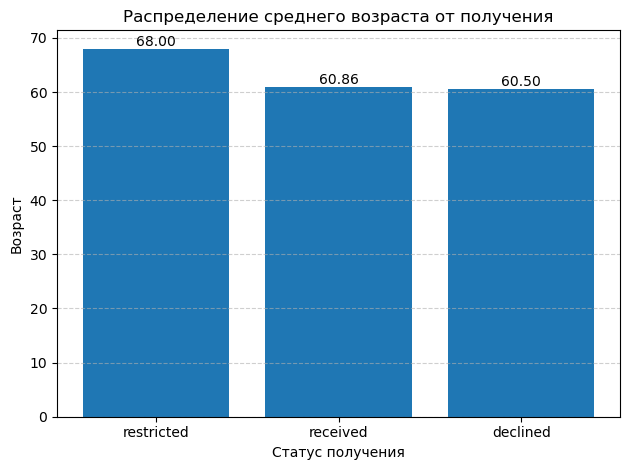

In [28]:
labels, values = table_to_plot_table(result_table, "prize_status", "avg_age_at_win")

x = list(range(len(labels)))
fig, ax = plt.subplots()
bars = ax.bar(x, values)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Возраст')
ax.set_xlabel('Статус получения')
ax.set_title('Распределение среднего возраста от получения')

ax.yaxis.grid(True, linestyle='--', alpha=0.6)

for rect, v in zip(bars, values):
    ax.text(rect.get_x() + rect.get_width()/2, rect.get_height(),
            f'{v:.2f}', ha='center', va='bottom')

plt.tight_layout()
_ = plt.show()

In [30]:
search_table = deepcopy(table)
whered_categories = where(search_table, "prize_no", lambda x: x == 1)
differed_categories = operation_column(whered_categories, ["award_year", "birth_year"], lambda x: x[0] - x[1])
renamed_categories = rename_column(differed_categories, "fun(award_year, birth_year)", "age_at_win")
grouped_categories = group_by(whered_categories, "SELECT AVG(age_at_win) category_en GROUP BY category_en")
result_table = rename_column(grouped_categories, "avg(age_at_win)", "avg_age_at_win")
pprint(result_table)

[{'avg_age_at_win': 60.94230769230769, 'category_en': 'Chemistry'},
 {'avg_age_at_win': 68.96969696969697, 'category_en': 'Economic Sciences'},
 {'avg_age_at_win': 59, 'category_en': 'Peace'},
 {'avg_age_at_win': 63.609756097560975, 'category_en': 'Literature'},
 {'avg_age_at_win': 60.58064516129032, 'category_en': 'Physics'},
 {'avg_age_at_win': 59, 'category_en': 'Physiology or Medicine'}]


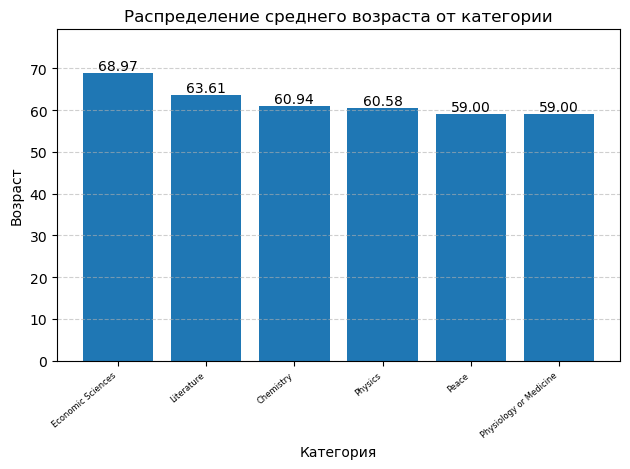

In [32]:
labels, values = table_to_plot_table(result_table, "category_en", "avg_age_at_win")

x = list(range(len(labels)))
fig, ax = plt.subplots()
bars = ax.bar(x, values)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Возраст')
ax.set_xlabel('Категория')
ax.set_xticklabels(labels, rotation=40, ha='right', fontsize=6)
ax.set_title('Распределение среднего возраста от категории')

ax.set_ylim(0, max(values) * 1.15)
ax.yaxis.grid(True, linestyle='--', alpha=0.6)

for rect, v in zip(bars, values):
    ax.text(rect.get_x() + rect.get_width()/2, rect.get_height(),
            f'{v:.2f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [34]:
search_table = deepcopy(table)
whered_people = where(search_table, "prize_no", lambda x: x == 1)
differed_people = operation_column(whered_people, ["award_year", "birth_year"], lambda x: x[0] - x[1])
renamed_people = rename_column(differed_people, "fun(award_year, birth_year)", "age_at_win")
filtered_people = where(renamed_people, "gender", lambda x: x)
grouped_people = group_by(filtered_people, "SELECT AVG(age_at_win) MEDIAN(age_at_win) prize_status GROUP BY prize_status")
renamed_1 = rename_column(grouped_people, "avg(age_at_win)", "avg_age_at_win")
result_table = rename_column(grouped_people, "median(age_at_win)", "median_avg_age_at_win")
pprint(result_table)

[{'avg_age_at_win': 60.86153846153846,
  'median_avg_age_at_win': 61,
  'prize_status': 'received'},
 {'avg_age_at_win': 68,
  'median_avg_age_at_win': 68,
  'prize_status': 'restricted'},
 {'avg_age_at_win': 60.5,
  'median_avg_age_at_win': 60.5,
  'prize_status': 'declined'}]


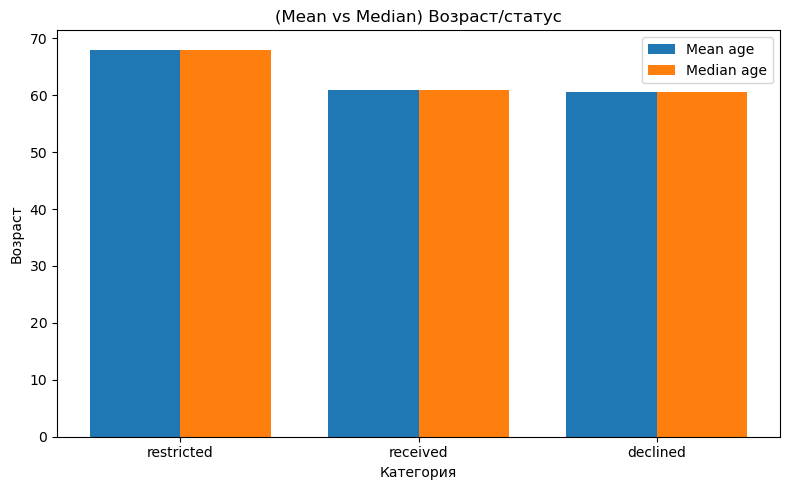

In [36]:
labels_mean, values_mean = table_to_plot_table(result_table, 'prize_status', 'avg_age_at_win')
    
median_map = {d['prize_status']: d['median_avg_age_at_win'] for d in result_table}
values_median = [median_map[lbl] for lbl in labels_mean]

x = list(range(len(labels_mean)))
width = 0.38
x_1 = [val - width/2 for val in x]
x_2 = [val + width/2 for val in x]

fig, ax = plt.subplots(figsize=(8, 5))
bars_mean = ax.bar(x_1, values_mean, width, label='Mean age', color='tab:blue')
bars_median = ax.bar(x_2, values_median, width, label='Median age', color='tab:orange')

ax.set_ylabel('Возраст')
ax.set_title('(Mean vs Median) Возраст/статус')
ax.set_xticks(x)
ax.set_xticklabels(labels_mean)
ax.set_xlabel('Категория')
ax.legend()

fig.tight_layout()
_ = plt.plot()

In [38]:
search_table = deepcopy(table)
whered_categories = where(search_table, "prize_no", lambda x: x == 1)
differed_categories = operation_column(whered_categories, ["award_year", "birth_year"], lambda x: x[0] - x[1])
renamed_categories = rename_column(differed_categories, "fun(award_year, birth_year)", "age_at_win")
grouped_people = group_by(filtered_people, "SELECT AVG(age_at_win) MEDIAN(age_at_win) category_en GROUP BY category_en")
renamed_1 = rename_column(grouped_people, "avg(age_at_win)", "avg_age_at_win")
result_table = rename_column(grouped_people, "median(age_at_win)", "median_avg_age_at_win")
pprint(result_table)

[{'avg_age_at_win': 60.94230769230769,
  'category_en': 'Chemistry',
  'median_avg_age_at_win': 60.5},
 {'avg_age_at_win': 68.96969696969697,
  'category_en': 'Economic Sciences',
  'median_avg_age_at_win': 69},
 {'avg_age_at_win': 59, 'category_en': 'Peace', 'median_avg_age_at_win': 60},
 {'avg_age_at_win': 63.609756097560975,
  'category_en': 'Literature',
  'median_avg_age_at_win': 63},
 {'avg_age_at_win': 60.58064516129032,
  'category_en': 'Physics',
  'median_avg_age_at_win': 60.5},
 {'avg_age_at_win': 59,
  'category_en': 'Physiology or Medicine',
  'median_avg_age_at_win': 59}]


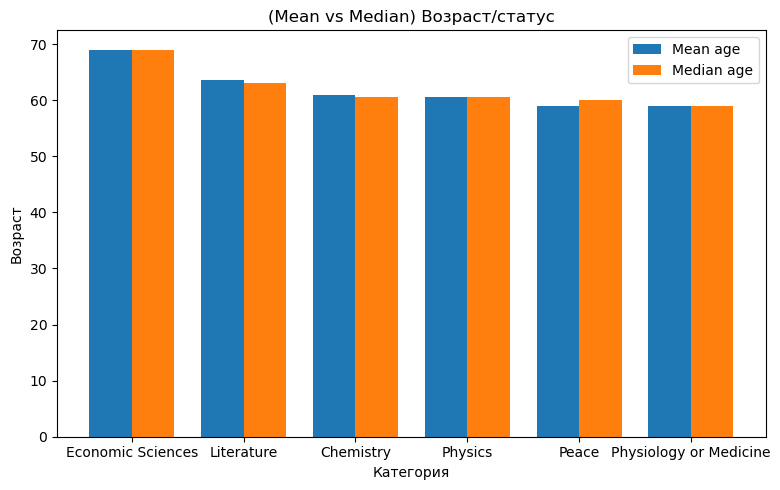

In [40]:
labels_mean, values_mean = table_to_plot_table(result_table, 'category_en', 'avg_age_at_win')
    
median_map = {d['category_en']: d['median_avg_age_at_win'] for d in result_table}
values_median = [median_map[lbl] for lbl in labels_mean]

x = list(range(len(labels_mean)))
width = 0.38
x_1 = [val - width/2 for val in x]
x_2 = [val + width/2 for val in x]

fig, ax = plt.subplots(figsize=(8, 5))
bars_mean = ax.bar(x_1, values_mean, width, label='Mean age', color='tab:blue')
bars_median = ax.bar(x_2, values_median, width, label='Median age', color='tab:orange')

ax.set_ylabel('Возраст')
ax.set_title('(Mean vs Median) Возраст/статус')
ax.set_xticks(x)
ax.set_xticklabels(labels_mean)
ax.set_xlabel('Категория')
ax.legend()

fig.tight_layout()
_ = plt.plot()

**2.3. Гендерное распределение**
- Как менялось количество женщин-лауреатов по десятилетиям?
- Сравните распределение лауреаток по категориям. Выведите значения суммарно за все годы и по декадам.
- В какой из категорий больше всего женщин лауреаток изначально и в последние пару десятилетий?

In [43]:
search_table = deepcopy(table)
filtered_people = where(search_table, "gender", lambda x: x == 'female')
decades_laureates = operation_column(filtered_people, ["award_year"], lambda x: int(str(x[0])[:-1]+"0"))
renamed_decades = rename_column(decades_laureates, "fun(award_year)", "decade")
grouped_decades = group_by(renamed_decades, "SELECT decade COUNT(id) GROUP BY decade")
result_table = rename_column(order_by(grouped_decades, "decade"), "count(id)", "number")
pprint(result_table)

[{'decade': 1900, 'number': 3},
 {'decade': 1910, 'number': 1},
 {'decade': 1920, 'number': 2},
 {'decade': 1930, 'number': 3},
 {'decade': 1940, 'number': 3},
 {'decade': 1960, 'number': 3},
 {'decade': 1970, 'number': 4},
 {'decade': 1980, 'number': 4},
 {'decade': 1990, 'number': 7},
 {'decade': 2000, 'number': 11},
 {'decade': 2010, 'number': 13},
 {'decade': 2020, 'number': 14}]


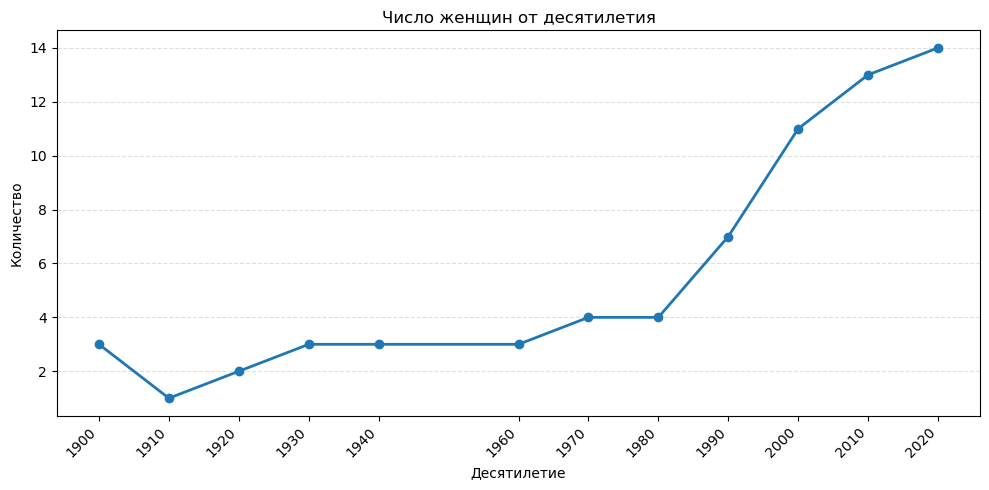

In [45]:
labels, values = table_to_plot_table(result_table, 'decade', 'number', True)

plt.figure(figsize=(10, 5))
plt.plot(labels, values, marker='o', linewidth=2)
plt.title("Число женщин от десятилетия")
plt.xlabel("Десятилетие")
plt.ylabel("Количество")
plt.xticks(labels, rotation=45, ha='right')
plt.grid(True, axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [47]:
search_table = deepcopy(table)
filtered_people = where(search_table, "gender", lambda x: x == 'female')
decades_laureates = operation_column(filtered_people, ["award_year"], lambda x: int(str(x[0])[:-1]+"0"))
renamed_decades = rename_column(decades_laureates, "fun(award_year)", "decade")
grouped_decades = group_by(renamed_decades, "SELECT decade category_en COUNT(id) GROUP BY decade category_en")
pprint(rename_column(order_by(grouped_decades, "decade"), "count(id)", "number"))

[{'category_en': 'Peace', 'decade': 1900, 'number': 1},
 {'category_en': 'Literature', 'decade': 1900, 'number': 1},
 {'category_en': 'Physics', 'decade': 1900, 'number': 1},
 {'category_en': 'Chemistry', 'decade': 1910, 'number': 1},
 {'category_en': 'Literature', 'decade': 1920, 'number': 2},
 {'category_en': 'Chemistry', 'decade': 1930, 'number': 1},
 {'category_en': 'Peace', 'decade': 1930, 'number': 1},
 {'category_en': 'Literature', 'decade': 1930, 'number': 1},
 {'category_en': 'Peace', 'decade': 1940, 'number': 1},
 {'category_en': 'Literature', 'decade': 1940, 'number': 1},
 {'category_en': 'Physiology or Medicine', 'decade': 1940, 'number': 1},
 {'category_en': 'Chemistry', 'decade': 1960, 'number': 1},
 {'category_en': 'Literature', 'decade': 1960, 'number': 1},
 {'category_en': 'Physics', 'decade': 1960, 'number': 1},
 {'category_en': 'Peace', 'decade': 1970, 'number': 3},
 {'category_en': 'Physiology or Medicine', 'decade': 1970, 'number': 1},
 {'category_en': 'Peace', 'de

In [50]:
search_table = deepcopy(table)
filtered_people = where(search_table, "gender", lambda x: x == 'female')
grouped_decades = group_by(filtered_people, "SELECT award_year category_en COUNT(id) GROUP BY award_year category_en")
pprint(rename_column(order_by(grouped_decades, "award_year"), "count(id)", "number"))

[{'award_year': 1903, 'category_en': 'Physics', 'number': 1},
 {'award_year': 1905, 'category_en': 'Peace', 'number': 1},
 {'award_year': 1909, 'category_en': 'Literature', 'number': 1},
 {'award_year': 1911, 'category_en': 'Chemistry', 'number': 1},
 {'award_year': 1926, 'category_en': 'Literature', 'number': 1},
 {'award_year': 1928, 'category_en': 'Literature', 'number': 1},
 {'award_year': 1931, 'category_en': 'Peace', 'number': 1},
 {'award_year': 1935, 'category_en': 'Chemistry', 'number': 1},
 {'award_year': 1938, 'category_en': 'Literature', 'number': 1},
 {'award_year': 1945, 'category_en': 'Literature', 'number': 1},
 {'award_year': 1946, 'category_en': 'Peace', 'number': 1},
 {'award_year': 1947, 'category_en': 'Physiology or Medicine', 'number': 1},
 {'award_year': 1963, 'category_en': 'Physics', 'number': 1},
 {'award_year': 1964, 'category_en': 'Chemistry', 'number': 1},
 {'award_year': 1966, 'category_en': 'Literature', 'number': 1},
 {'award_year': 1976, 'category_en': 

**2.5. Многократные лауреаты**
- Найдите лауреатов, получившие больше одного приза. Кто получил больше 2 раз? 
- Совпадает ли категория второго приза с первой?  
- Сколько в среднем времени прошло между получением первой и второй премии?

In [53]:
search_table = deepcopy(table)
grouped_count = group_by(search_table, "SELECT name COUNT(award_year) GROUP BY name")
pprint(rename_column(where(grouped_count, "count(award_year)", lambda x: x>1), "count(award_year)", "number"))

[{'name': 'Marie Curie', 'number': 2},
 {'name': 'John Bardeen', 'number': 2},
 {'name': 'International Committee of the Red Cross', 'number': 3},
 {'name': 'Frederick Sanger', 'number': 2},
 {'name': 'Linus Pauling', 'number': 2},
 {'name': 'Office of the United Nations High Commissioner for Refugees',
  'number': 2},
 {'name': 'K. Barry Sharpless', 'number': 2}]


Организаций таких несколько, кто получил несколько наград. И есть одна, которая получила и больше 2 наград, причем внутри одной категории:

In [56]:
search_table = deepcopy(table)
filtered_org = where(search_table, "name", lambda x: x == 'International Committee of the Red Cross')
grouped_count = group_by(filtered_people, "SELECT category_en name COUNT(award_year) GROUP BY category_en name")
pprint(rename_column(grouped_count, "count(award_year)", "number"))

[{'category_en': 'Chemistry', 'name': 'Ada E. Yonath', 'number': 1},
 {'category_en': 'Chemistry', 'name': 'Jennifer A. Doudna', 'number': 1},
 {'category_en': 'Chemistry', 'name': 'Carolyn Bertozzi', 'number': 1},
 {'category_en': 'Chemistry', 'name': 'Irène Joliot-Curie', 'number': 1},
 {'category_en': 'Chemistry', 'name': 'Frances H. Arnold', 'number': 1},
 {'category_en': 'Chemistry', 'name': 'Marie Curie', 'number': 1},
 {'category_en': 'Chemistry', 'name': 'Dorothy Crowfoot Hodgkin', 'number': 1},
 {'category_en': 'Chemistry', 'name': 'Emmanuelle Charpentier', 'number': 1},
 {'category_en': 'Economic Sciences', 'name': 'Elinor Ostrom', 'number': 1},
 {'category_en': 'Economic Sciences', 'name': 'Esther Duflo', 'number': 1},
 {'category_en': 'Economic Sciences', 'name': 'Claudia Goldin', 'number': 1},
 {'category_en': 'Peace', 'name': 'Bertha von Suttner', 'number': 1},
 {'category_en': 'Peace', 'name': 'Maria Corina Machado', 'number': 1},
 {'category_en': 'Peace', 'name': 'Mothe

In [58]:
pprint(filtered_org)

[{'award_year': 1963,
  'category_en': 'Peace',
  'country_founded': 'Switzerland',
  'country_now': 'Switzerland',
  'founded_year': 1863,
  'id': '482',
  'name': 'International Committee of the Red Cross',
  'prize_amount': 265000,
  'prize_amount_adjusted': 3590371,
  'prize_no': 1,
  'prize_status': 'received'},
 {'award_year': 1917,
  'category_en': 'Peace',
  'country_founded': 'Switzerland',
  'country_now': 'Switzerland',
  'founded_year': 1863,
  'id': '482',
  'name': 'International Committee of the Red Cross',
  'prize_amount': 133823,
  'prize_amount_adjusted': 4957724,
  'prize_no': 2,
  'prize_status': 'received'},
 {'award_year': 1944,
  'category_en': 'Peace',
  'country_founded': 'Switzerland',
  'country_now': 'Switzerland',
  'founded_year': 1863,
  'id': '482',
  'name': 'International Committee of the Red Cross',
  'prize_amount': 121841,
  'prize_amount_adjusted': 3174561,
  'prize_no': 3,
  'prize_status': 'received'}]


**2.6 Отказы от премий**
- Определите, в каких категориях чаще отказывались от премий?
- Есть ли отказы среди организаций

In [61]:
search_table = deepcopy(table)
filtered_org = where(search_table, "prize_status", lambda x: x == 'declined')
grouped_count = group_by(filtered_org, "SELECT name country_now category_en COUNT(prize_amount_adjusted) GROUP BY name country_now category_en")
pprint(rename_column(grouped_count, "count(prize_amount_adjusted)", "number"))

[{'category_en': 'Peace',
  'country_now': 'Vietnam',
  'name': 'Le Duc Tho ',
  'number': 1},
 {'category_en': 'Literature',
  'country_now': 'France',
  'name': 'Jean-Paul Sartre',
  'number': 1}]


Отказов не так много, один за мир и один за литературу, отказывались только люди

---------

## Бонусное задание на +2 балла


### Лингвистический анализ мотиваций**

**5.1. Анализ текстов мотиваций**
- Соберите корпус текстов мотиваций вручения премий. Для этого измените конфиг обработки призов.
- Выделите самые частые топ-50 слов. Какие из этих слов самые частые в принципе в английском языке (такие, как for, the и другие), а какие кажутся важными именно в контексте вручения Нобелевской премии (например, 'chemistry')?
- Самые частые слова, которые также являются частыми во всем английском языке занесите в отдельный конфиг-файл под названием `stopwords.py`. Вычистите их из текстов. Какие слова являются самыми частыми теперь? Сравните множества топ-10 самых частых слов по разным категориям


- Если есть желание, посчитайте TF-IDF + сравнените топ слов по этой метрике с просто самыми популярными словами)